# Connessione al db

In [7]:
import pandas as pd
import numpy as np
from connessioni import get_mysql_connection

# Configurazione pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\venv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.10) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [8]:
conn = get_mysql_connection()

# Carica tutti i dati da raw_data in un DataFrame
query = "SELECT * FROM clean_data"
df = pd.read_sql(query, conn)

conn.close()

print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")
df.head()

Dataset caricato: 144 righe, 37 colonne


C:\Users\Utente\AppData\Local\Temp\ipykernel_25076\3523368477.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,email,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15,Item_16,Item_17,Item_18,Item_19,Item_20,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30
0,1,None,Entrambi,24,Femmina,Nord Italia,5.0,4,5,4,4,4,4.0,4.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5,5,1,1,2,2,4,5,5,Durante gli esami e se devo interagire con gli...
1,2,None,Studio,26,Femmina,Nord Italia,7.0,4,5,3,4,3,4.0,3.0,2.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,NaN,NaN,NaN,NaN,NaN,4,1,3,3,5,2,2,2,4,Durante gli esami
2,3,None,Lavoro,26,Maschio,Nord Italia,5.0,3,4,3,4,4,4.0,5.0,3.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,4.0,2.0,4.0,5.0,5.0,3,5,1,1,4,2,5,4,5,Interazione con persone (clienti)
3,4,None,Entrambi,26,Femmina,Nord Italia,5.0,2,4,3,5,5,3.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,5.0,3.0,5.0,3.0,2,5,3,3,2,3,2,1,3,L’esame
4,5,None,Studio,22,Femmina,Nord Italia,2.0,3,2,3,4,4,3.0,2.0,2.0,3.0,1.0,4.0,3.0,3.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,2,2,3,2,4,3,3,2,4,"Durante il tirocinio, quando devo mettere effe..."


# Calcolo degli indici

In [ ]:
df["ansia_prestazione"] = df[["Item_1", "Item_2", "Item_3", "Item_4", "Item_6", "Item_11", "Item_20", "Item_21"]].mean(axis=1)
df["ansia_accademica"] = df[["Item_7", "Item_8", "Item_9", "Item_10"]].mean(axis=1)
df["ansia_lavorativa"] = df[["Item_12", "Item_13", "Item_14", "Item_15"]].mean(axis=1)
df["perfezionismo"] = df[["Item_16", "Item_17", "Item_18", "Item_19"]].mean(axis=1)
df["impatto_ansia"] = df[["Item_5", "Item_22", "Item_27", "Item_28", "Item_29"]].mean(axis=1)
df["coping"] = df[["Item_23", "Item_24", "Item_25", "Item_26"]].mean(axis=1)

In [26]:
df['ansia'] = df[["ansia_prestazione", "ansia_accademica", "ansia_lavorativa"]].mean(axis=1)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 43 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 144 non-null    int64  
 1   email              12 non-null     object 
 2   contesto           144 non-null    object 
 3   età                144 non-null    int64  
 4   genere             144 non-null    object 
 5   area_geo           144 non-null    object 
 6   anni_esperienza    144 non-null    float64
 7   Item_1             144 non-null    int64  
 8   Item_2             144 non-null    int64  
 9   Item_3             144 non-null    int64  
 10  Item_4             144 non-null    int64  
 11  Item_5             144 non-null    int64  
 12  Item_6             141 non-null    float64
 13  Item_7             141 non-null    float64
 14  Item_8             141 non-null    float64
 15  Item_9             142 non-null    float64
 16  Item_10            140 non

# Distribuzioni

(array([0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5]),
 [Text(0.5, 0, '0.5'),
  Text(1.0, 0, '1.0'),
  Text(1.5, 0, '1.5'),
  Text(2.0, 0, '2.0'),
  Text(2.5, 0, '2.5'),
  Text(3.0, 0, '3.0'),
  Text(3.5, 0, '3.5'),
  Text(4.0, 0, '4.0'),
  Text(4.5, 0, '4.5'),
  Text(5.0, 0, '5.0'),
  Text(5.5, 0, '5.5')])

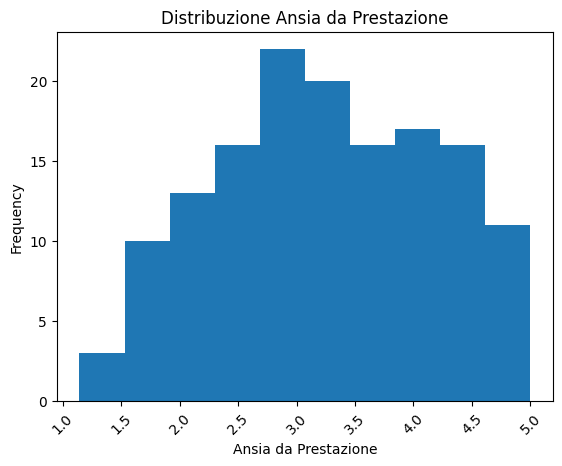

In [19]:
import matplotlib.pyplot as plt

df["ansia_prestazione"].plot(kind = 'hist')
plt.xlabel('Ansia da Prestazione')
plt.title('Distribuzione Ansia da Prestazione')
plt.xticks(rotation=45)

# Correlazioni

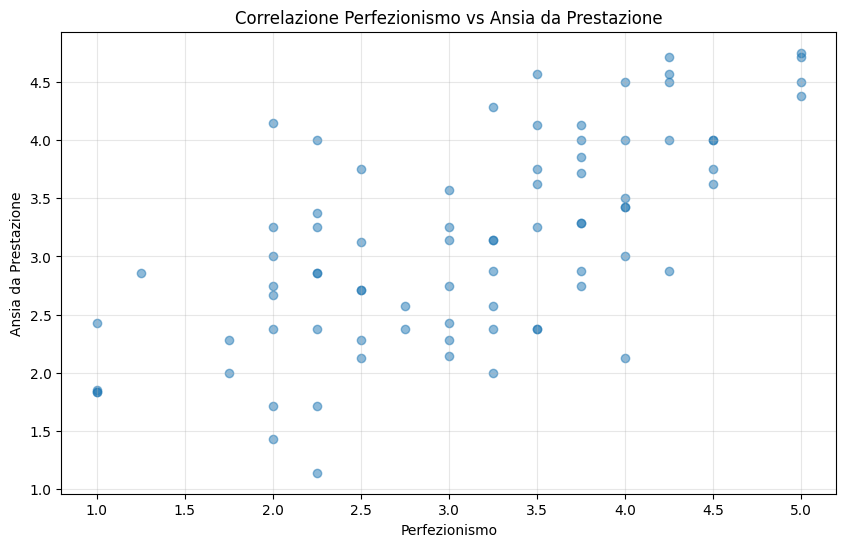

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df["perfezionismo"], df["ansia_prestazione"], alpha=0.5)
plt.xlabel('Perfezionismo')
plt.ylabel('Ansia da Prestazione')
plt.title(f'Correlazione Perfezionismo vs Ansia da Prestazione')
plt.grid(True, alpha=0.3)

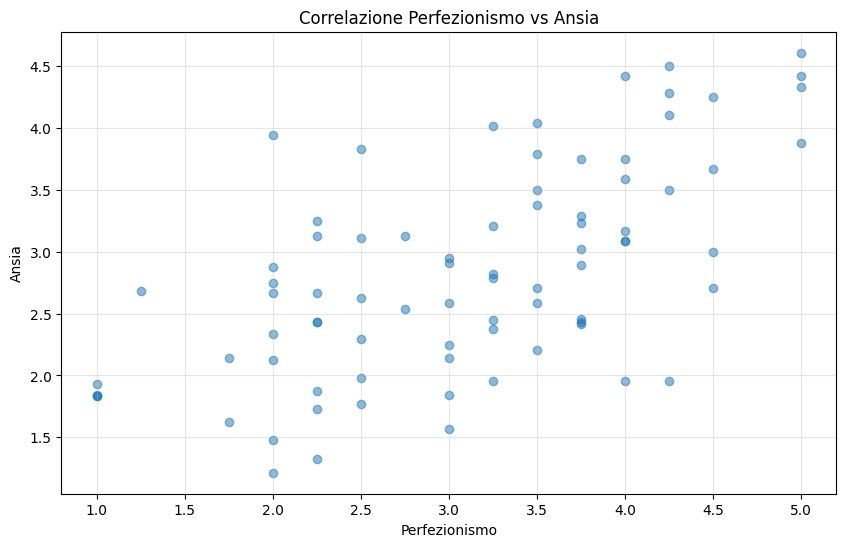

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(df["perfezionismo"], df["ansia"], alpha=0.5)
plt.xlabel('Perfezionismo')
plt.ylabel('Ansia')
plt.title(f'Correlazione Perfezionismo vs Ansia')
plt.grid(True, alpha=0.3)

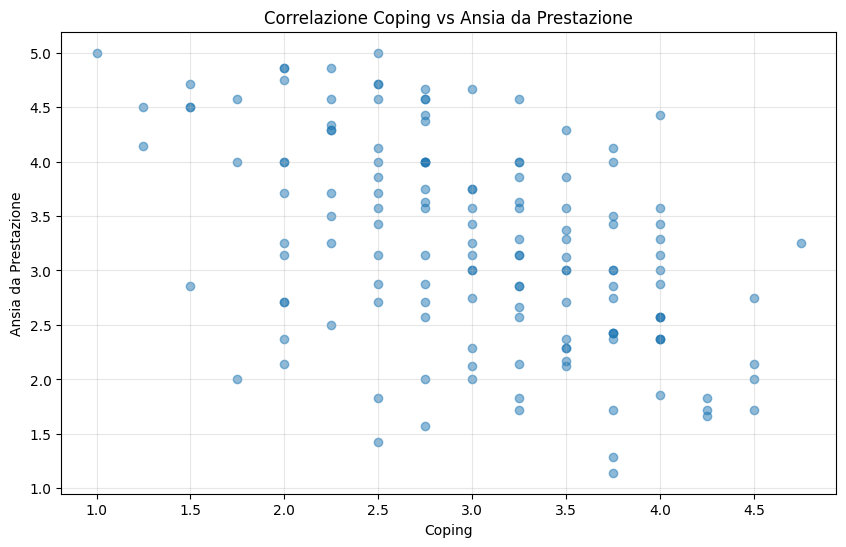

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(df["coping"], df["ansia_prestazione"], alpha=0.5)
plt.xlabel('Coping')
plt.ylabel('Ansia da Prestazione')
plt.title(f'Correlazione Coping vs Ansia da Prestazione')
plt.grid(True, alpha=0.3)

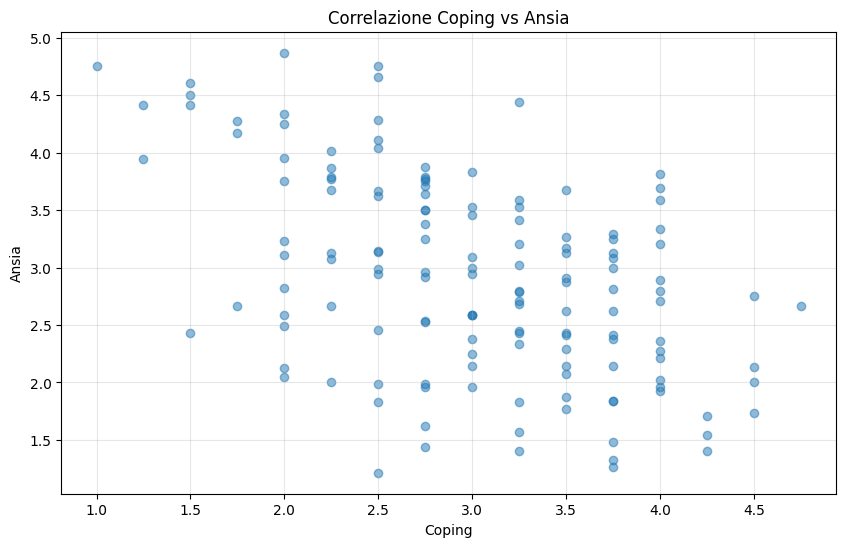

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(df["coping"], df["ansia"], alpha=0.5)
plt.xlabel('Coping')
plt.ylabel('Ansia')
plt.title(f'Correlazione Coping vs Ansia')
plt.grid(True, alpha=0.3)